In [2]:
import sys
sys.path.append("..")
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import json
from datetime import datetime
from datasets import load_from_disk

from torch.utils.data import DataLoader

In [3]:
# Загрузка модели, корневая папка проекта
from src.data import PROJECT_ROOT, load_model_and_tokenizer, RuleTakerDataset, estimate_max_length
from src.probing import run_probing_experiment

In [4]:
sns.set_style("whitegrid")

In [5]:
CACHE_DIR = PROJECT_ROOT / "data/processed"
RESULTS_DIR = PROJECT_ROOT / "results/probing"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Эксперименты по зондированию на Pythia-410m

## Эксперимент 2: Pythia-410m + depth-2

In [6]:
# Параметры эксперимента
VARIANT = "depth-2"
MODEL_SIZE = "410m"
USE_SMALL = True
HOOK_NAME = "resid_post"
POOLING = "last"
BATCH_SIZE = 16

### Подготовка модели и данных

In [30]:
model, tokenizer = load_model_and_tokenizer(model_size=MODEL_SIZE, device="cuda")
model.eval()

Loaded pretrained model EleutherAI/pythia-410m-deduped into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-23): 24 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
    

In [8]:
# Загружаем усеченную версию датасета
cache_suffix = f"{VARIANT}_small" if USE_SMALL else VARIANT
cache_path = CACHE_DIR / f"ruletaker_{cache_suffix}"
dataset = load_from_disk(str(cache_path))

In [9]:
# если выборка до 5000 наблюдений
tmp_tokens = tokenizer(list(dataset["train"]["text"]), padding=False, truncation=False)
lengths = [len(ids) for ids in tmp_tokens['input_ids']]
max_full = max(lengths)
max_p95 = int(np.percentile(lengths, 95))
print(f"95-й перцентиль: {max_p95} токенов (при макс длине {max_full})")

95-й перцентиль: 203 токенов (при макс длине 256)


Согласно документации, Pythia-410m поддерживает длину контекстного окна 2048 токенов (предел для суммы "вопрос + ответ"). Тексты depth-1 согласно анализу (01_data_setup.ipynb) имеют максимальную длину ~1200 символов, что составляет максимум 258 токенов (для обычных текстов такая такая длина составила бы ~400 токенов), что создает достаточный запас для защиты от возникновения ООМ. Для экономии памяти можно также воспользоваться подходом с обрезкой по 95-ому перцентилю

In [10]:
# max_p95 = estimate_max_length(list(dataset["train"]["text"]), tokenizer, percentile=95, sample_size=500)

In [11]:
MAX_LENGTH = max_p95

In [12]:
train_dataset = RuleTakerDataset(dataset["train"], tokenizer, max_length=MAX_LENGTH)
dev_dataset = RuleTakerDataset(dataset["dev"], tokenizer, max_length=MAX_LENGTH)

In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)

### Метод probing classifiers

In [14]:
n_layers = model.cfg.n_layers
d_model = model.cfg.d_model

In [15]:
n_layers

24

В архитектуре Pythia-410m 24 слоя. В тренировочной выборке 500 примеров по 256 токенов, таким образом один слой требует 500 * 256 * 1024 * 4 байта ~ 500мб. Для 24 слоев это 500 * 24 ~ 12 Гб видеопамяти, что в 2 раза превышает допустимый объем. В связи с чем используем итеративный пробинг

In [16]:
torch.cuda.empty_cache()

In [17]:
# Кэшируем активации
results = run_probing_experiment(
    model, train_loader, dev_loader, n_layers,
    hook_name=HOOK_NAME, pooling=POOLING
)

Probing layers: 100%|██████████| 24/24 [22:26<00:00, 56.10s/it]


In [24]:
# Извлечение данных для графиков
train_accs = results["train_accs"]
dev_accs = results["dev_accs"]
train_means = [s["mean_abs"] for s in results["train_stats"]]
dev_means = [s["mean_abs"] for s in results["dev_stats"]]
train_stds = [s["std_abs"] for s in results["train_stats"]]
dev_stds = [s["std_abs"] for s in results["dev_stats"]]
train_sparsity = [s["sparsity"] for s in results["train_stats"]]
dev_sparsity = [s["sparsity"] for s in results["dev_stats"]]

In [25]:
# Визуализация результатов
best_layer = int(np.argmax(dev_accs))
best_train_acc = float(train_accs[best_layer])
best_dev_acc = float(dev_accs[best_layer])
print(f"Лучший слой: {best_layer} (0-based), Dev Accuracy: {best_dev_acc:.4f}")

Лучший слой: 23 (0-based), Dev Accuracy: 0.5460


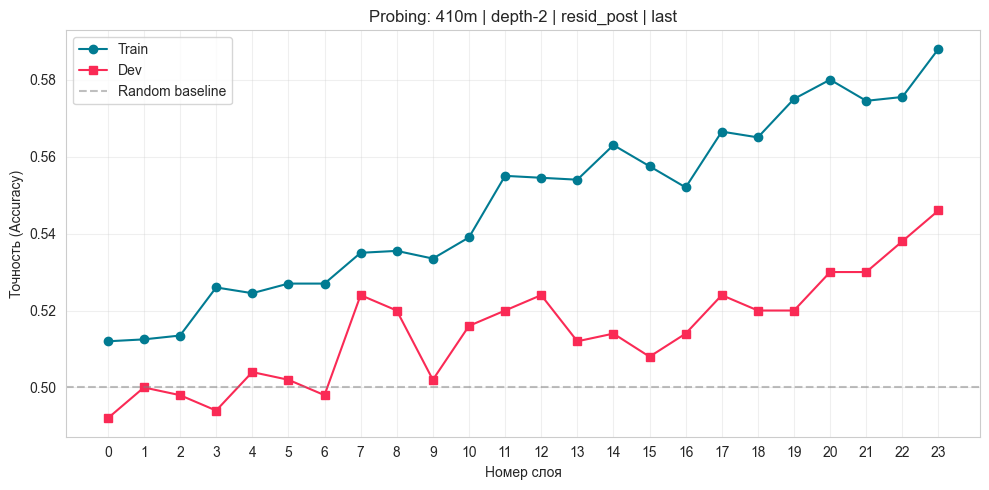

In [26]:
plt.figure(figsize=(10, 5))
x = np.arange(n_layers)
plt.plot(x, train_accs, marker="o", label="Train", color="xkcd:ocean")
plt.plot(x, dev_accs, marker="s", label="Dev", color="xkcd:red pink")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Random baseline")
plt.xlabel("Номер слоя")
plt.ylabel("Точность (Accuracy)")
plt.title(f"Probing: {MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING}")
plt.xticks(x)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

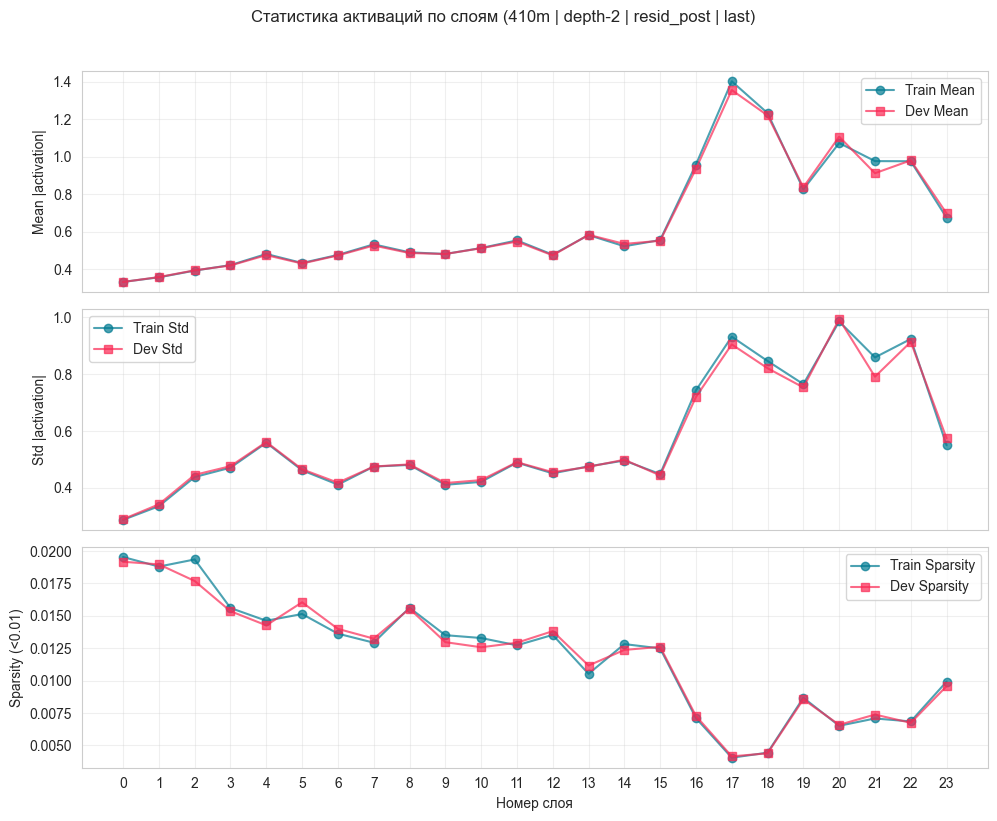

In [27]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax1.plot(x, train_means, marker="o", label="Train Mean", color="xkcd:ocean", alpha=0.7)
ax1.plot(x, dev_means, marker="s", label="Dev Mean", color="xkcd:red pink", alpha=0.7)
ax1.set_ylabel("Mean |activation|")
ax1.set_xticks(x)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(x, train_stds, marker="o", label="Train Std", color="xkcd:ocean", alpha=0.7)
ax2.plot(x, dev_stds, marker="s", label="Dev Std", color="xkcd:red pink", alpha=0.7)
ax2.set_ylabel("Std |activation|")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(x, train_sparsity, marker="o", label="Train Sparsity", color="xkcd:ocean", alpha=0.7)
ax3.plot(x, dev_sparsity, marker="s", label="Dev Sparsity", color="xkcd:red pink", alpha=0.7)
ax3.set_ylabel("Sparsity (<0.01)")
ax3.set_xlabel("Номер слоя")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle(f"Статистика активаций по слоям ({MODEL_SIZE} | {VARIANT} | {HOOK_NAME} | {POOLING})", y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Сохранение метрик в JSON
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
fname = f"probe_{MODEL_SIZE}_{VARIANT}_{HOOK_NAME}_{POOLING}_{ts}.json"
fpath = RESULTS_DIR / fname

metrics = {
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "best_layer": best_layer,
    "best_dev_acc": float(best_dev_acc),
    "train_accs": [float(a) for a in train_accs],
    "dev_accs": [float(a) for a in dev_accs]
}

# Исходные условия эксперимента
metadata = {
    "experiment_type": "probing_layer_selection",
    "timestamp": datetime.now().isoformat(),
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "hook_name": HOOK_NAME,
    "pooling": POOLING,
    "batch_size": BATCH_SIZE,
    "max_length": MAX_LENGTH
}

# Основной результат
summary = {
    "best_layer": best_layer,
    "best_train_acc": best_train_acc,
    "best_dev_acc": best_dev_acc,
    "n_layers": len(results["layers"])
}

# Свод
full_data = {
    "metadata": metadata,
    "summary": summary,
    "layers": results["layers"],
    "train_accs": [float(x) for x in results["train_accs"]],
    "dev_accs": [float(x) for x in results["dev_accs"]],
    "train_stats": results["train_stats"],
    "dev_stats": results["dev_stats"]
}

with open(fpath, "w", encoding="utf-8") as f:
    json.dump(full_data, f, indent=2, ensure_ascii=False)
print(f"Результаты сохранены: {fpath}")

Результаты сохранены: C:\MyPythonProjects\mephi_diss\results\probing\probe_410m_depth-2_resid_post_last_20260405_022807.json


In [31]:
# Очистка памяти
del model
torch.cuda.empty_cache()